In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 무시 설정
import warnings
warnings.filterwarnings(action='ignore')

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 종근당건강

In [2]:
df01 = pd.read_csv('./senior.csv')
df01

,name
0,6년근홍삼정
1,관절연골엔 난각막NEM
2,관절연골엔 난각막NEM 프리미엄
3,눈건강 간건강 면역건강 활력
4,눈건강엔 루테인지아잔틴
...,...
60,홍삼이뮨스틱
61,홍삼정마일드
62,홍삼정스틱
63,활력녹용단


In [3]:
df02 = pd.read_csv('./product.csv')
df02

,name
0,6년근홍삼정
1,관절연골엔 난각막NEM
2,관절연골엔 난각막NEM 프리미엄
3,눈건강 간건강 면역건강 활력
4,눈건강엔 루테인지아잔틴
...,...
93,홍삼더부스터샷
94,홍삼스틱
95,홍삼이뮨스틱
96,홍삼정마일드


In [4]:
# df01과 df02의 'name' 컬럼을 기준으로 교집합(inner join) 수행
df_common = pd.merge(df01, df02, on='name', how='inner')

# 결과 확인
print(f"공통 제품 개수: {len(df_common)}개")
df_common

공통 제품 개수: 48개


,name
0,6년근홍삼정
1,관절연골엔 난각막NEM
2,관절연골엔 난각막NEM 프리미엄
3,눈건강 간건강 면역건강 활력
4,눈건강엔 루테인지아잔틴
5,락토핏 골드
6,락토핏 골드 17포
7,락토핏 골드 선물세트
8,락토핏 골드80포
9,락토핏 생유산균 팜(약국전용)


In [5]:
# 'common_products.csv'라는 이름으로 저장합니다.
# encoding='utf-8-sig'를 사용해야 엑셀(Excel)에서 한글이 깨지지 않고 잘 보입니다.
df_common.to_csv('종근당건강.csv', index=False, encoding='utf-8-sig')

print("공통 제품 리스트가 '종근당건강.csv'로 저장되었습니다.")

공통 제품 리스트가 '종근당건강.csv'로 저장되었습니다.


## 종근당건강 정보 업데이트

In [6]:
df1 = pd.read_csv('./종근당건강.csv')
df1

,name
0,6년근홍삼정
1,관절연골엔 난각막NEM
2,관절연골엔 난각막NEM 프리미엄
3,눈건강 간건강 면역건강 활력
4,눈건강엔 루테인지아잔틴
5,락토핏 골드
6,락토핏 골드 17포
7,락토핏 골드 선물세트
8,락토핏 골드80포
9,락토핏 생유산균 팜(약국전용)


In [7]:
df2 = pd.read_csv('./전국건강기능식품영양성분정보표준데이터.csv', encoding = 'cp949')
df2

,식품코드,식품명,데이터구분코드,데이터구분명,식품기원코드,식품기원명,식품대분류코드,식품대분류명,대표식품코드,대표식품명,...,유통업체명,수입여부,원산지국코드,원산지국명,데이터생성방법코드,데이터생성방법명,데이터생성일자,데이터기생성일자,제공기관코드,제공기관명
0,F103-001010000-0001,100억 생유산균 프로바이오틱스 플러스 아연 셀레늄,F,건강기능식품,1,건강기능식품,3,복합,3001,"복합제품(영양소, 기능성)",...,해당없음,Y,124,캐나다,2,수집,2023-08-09,2025-12-30,1471000,식품의약품안전처
1,F102-050500000-0001,100억 유산균,F,건강기능식품,1,건강기능식품,2,기능성 원료,2050,프로바이오틱스,...,해당없음,Y,124,캐나다,2,수집,2025-04-29,2025-12-30,1471000,식품의약품안전처
2,F102-050500000-0002,100억 유산균 2.0,F,건강기능식품,1,건강기능식품,2,기능성 원료,2050,프로바이오틱스,...,해당없음,Y,124,캐나다,2,수집,2023-11-13,2025-12-30,1471000,식품의약품안전처
3,F102-050500000-0003,100억 유산균 알파,F,건강기능식품,1,건강기능식품,2,기능성 원료,2050,프로바이오틱스,...,해당없음,Y,124,캐나다,2,수집,2023-08-02,2025-12-30,1471000,식품의약품안전처
4,F102-050500000-0004,100억 프로바이오틱스 골드,F,건강기능식품,1,건강기능식품,2,기능성 원료,2050,프로바이오틱스,...,해당없음,Y,124,캐나다,2,수집,2022-03-23,2025-12-30,1471000,식품의약품안전처
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4375,F101-016160000-0030,힐리 마그네슘 500,F,건강기능식품,1,건강기능식품,1,영양성분,1016,마그네슘,...,해당없음,Y,840,미국,2,수집,2022-09-20,2025-12-30,1471000,식품의약품안전처
4376,F101-013130000-0044,힐리 비오틴 10000,F,건강기능식품,1,건강기능식품,1,영양성분,1013,비오틴,...,해당없음,Y,840,미국,2,수집,2022-09-20,2025-12-30,1471000,식품의약품안전처
4377,F101-003030000-0144,힐리 비타민D 5000,F,건강기능식품,1,건강기능식품,1,영양성분,1003,비타민 D,...,해당없음,Y,840,미국,2,수집,2022-08-16,2025-12-30,1471000,식품의약품안전처
4378,F101-020200000-0003,힐리 셀레늄 300,F,건강기능식품,1,건강기능식품,1,영양성분,1020,셀레늄,...,해당없음,Y,840,미국,2,수집,2022-07-18,2025-12-30,1471000,식품의약품안전처


In [8]:
# 데이터 전처리 (공백으로 인한 매칭 실패 방지)
df1['name'] = df1['name'].str.strip()
df2['식품명'] = df2['식품명'].str.strip()

In [9]:
df_merged = pd.merge(df1, df2, left_on='name', right_on='식품명', how='inner')
df_merged

,name,식품코드,식품명,데이터구분코드,데이터구분명,식품기원코드,식품기원명,식품대분류코드,식품대분류명,대표식품코드,...,유통업체명,수입여부,원산지국코드,원산지국명,데이터생성방법코드,데이터생성방법명,데이터생성일자,데이터기생성일자,제공기관코드,제공기관명


## 종근당건강 영양 함량 분석

In [10]:
df_info = pd.read_csv('./종근당건강_영양성분정보.csv')
df_info

,name,섭취방식,에너지,단백질,탄수화물,칼슘,인,철,나트륨,칼륨,비타민A,티아민,리보플라빈,나이아신,비타민C,엽산
0,6년근홍삼정,액상,10.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,관절연골엔 난각막NEM,캡슐,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,관절연골엔 난각막NEM 프리미엄,캡슐,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,700.0,1.2,NaN,NaN,NaN,NaN
3,눈건강 간건강 면역건강 활력,캡슐,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,NaN,NaN,NaN
4,눈건강엔 루테인지아잔틴,캡슐,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,700.0,1.2,1.4,NaN,NaN,NaN
5,락토핏 골드,분말,10.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,락토핏 솔루션 1 둔감한장,캡슐,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,락토핏 솔루션 2 예민한 장,캡슐,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,락토핏 식물성,분말,10.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,락토핏 인지력케어,분말,10.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_info = df_info.fillna(0)
df_info

,name,섭취방식,에너지,단백질,탄수화물,칼슘,인,철,나트륨,칼륨,비타민A,티아민,리보플라빈,나이아신,비타민C,엽산
0,6년근홍삼정,액상,10.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,관절연골엔 난각막NEM,캡슐,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,관절연골엔 난각막NEM 프리미엄,캡슐,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,700.0,1.2,0.0,0.0,0.0,0.0
3,눈건강 간건강 면역건강 활력,캡슐,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,7.0,0.0,0.0,0.0
4,눈건강엔 루테인지아잔틴,캡슐,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,700.0,1.2,1.4,0.0,0.0,0.0
5,락토핏 골드,분말,10.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,락토핏 솔루션 1 둔감한장,캡슐,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,락토핏 솔루션 2 예민한 장,캡슐,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,락토핏 식물성,분말,10.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,락토핏 인지력케어,분말,10.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


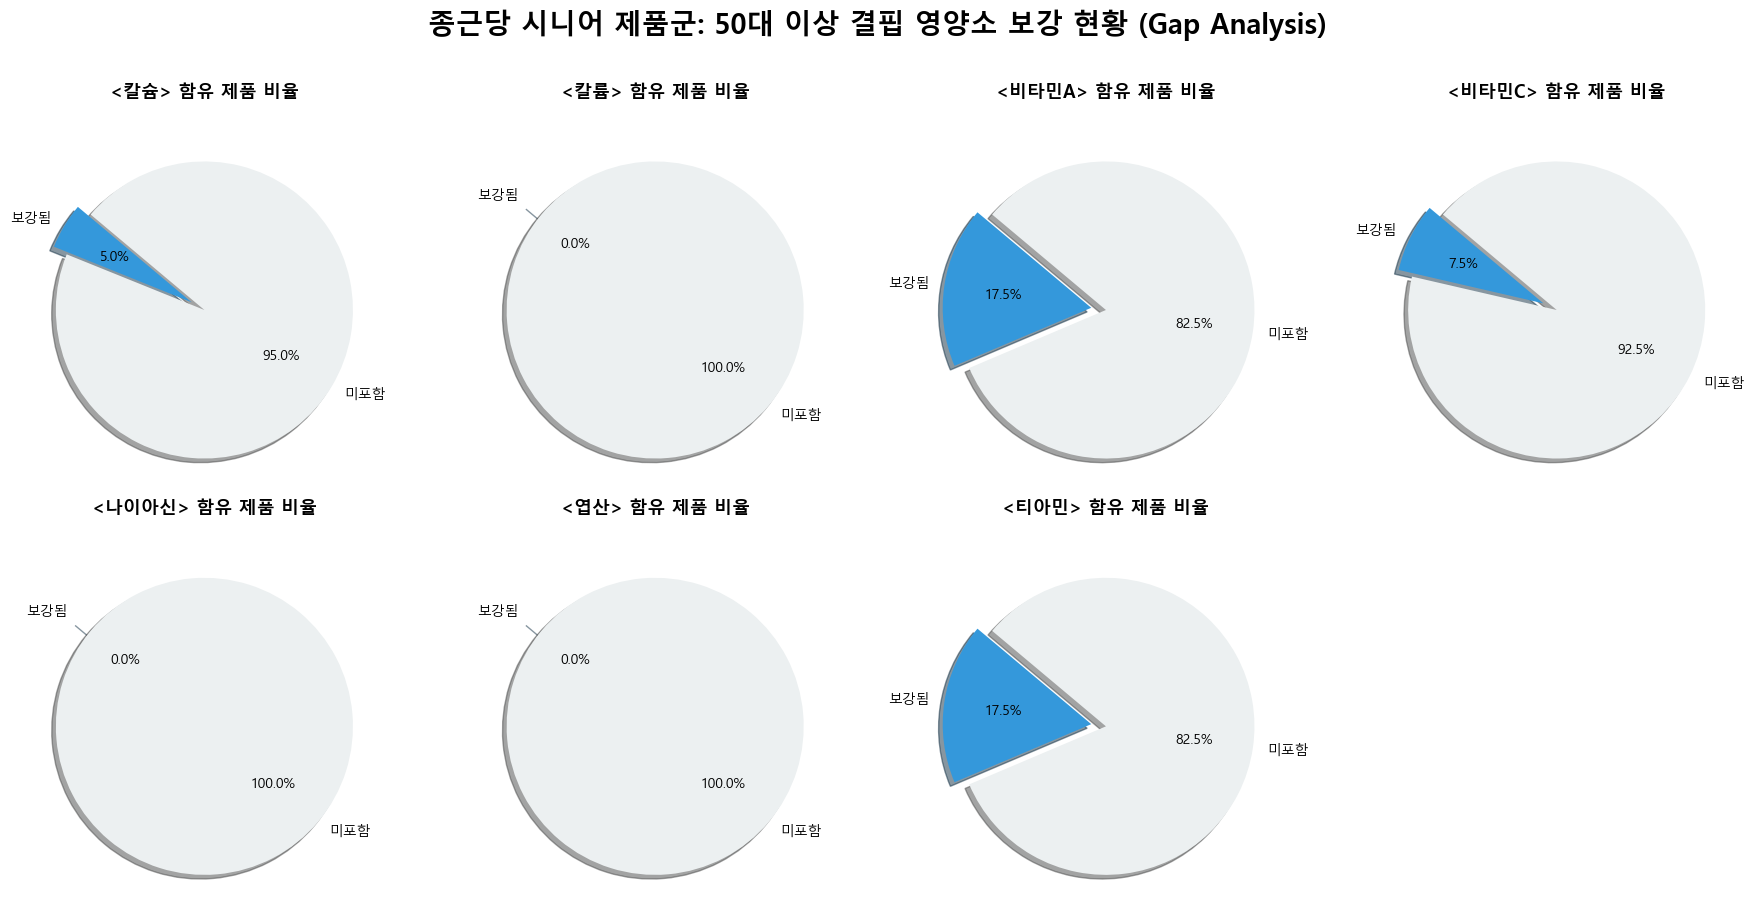

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# 1. 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def clean_nutrient_value(value):
    """문자열에서 숫자만 추출하여 float로 변환하는 함수"""
    if pd.isna(value) or value == '0' or value == '-':
        return 0.0
    # 숫자와 소수점만 남기고 제거 (예: '10mg' -> '10')
    try:
        num = re.sub(r'[^0-9.]', '', str(value))
        return float(num) if num else 0.0
    except:
        return 0.0

def plot_nutrient_pie_charts(df):
    # 분석 타겟 결핍 영양소 (50대 이상 결핍 항목)
    target_nutrients = ['칼슘', '칼륨', '비타민A', '비타민C', '나이아신', '엽산', '티아민']
    
    # 실제 df_info에 있는 컬럼만 선별
    valid_cols = [col for col in target_nutrients if col in df.columns]
    
    if not valid_cols:
        print("데이터프레임에 해당 영양소 컬럼이 없습니다. 컬럼명을 확인해주세요.")
        return

    # 그래프 배치 설정 (2행 4열 등)
    num_plots = len(valid_cols)
    cols = 4
    rows = (num_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4.5))
    axes = axes.flatten()

    for i, col in enumerate(valid_cols):
        # 데이터 전처리: 숫자형으로 변환하여 0보다 큰지 확인
        temp_series = df[col].apply(clean_nutrient_value)
        
        contains_count = (temp_series > 0).sum()
        missing_count = len(df) - contains_count
        
        # 파이 차트 데이터
        sizes = [contains_count, missing_count]
        labels = ['보강됨', '미포함']
        colors = ['#3498db', '#ecf0f1']  # 보강됨(파랑), 미포함(연회색)

        # 차트 그리기
        axes[i].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, 
                    colors=colors, explode=(0.1, 0), shadow=True)
        axes[i].set_title(f'<{col}> 함유 제품 비율', fontsize=13, fontweight='bold', pad=20)

    # 빈 서브플롯 제거
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('종근당 시니어 제품군: 50대 이상 결핍 영양소 보강 현황 (Gap Analysis)', 
                 fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# 실행
plot_nutrient_pie_charts(df_info)

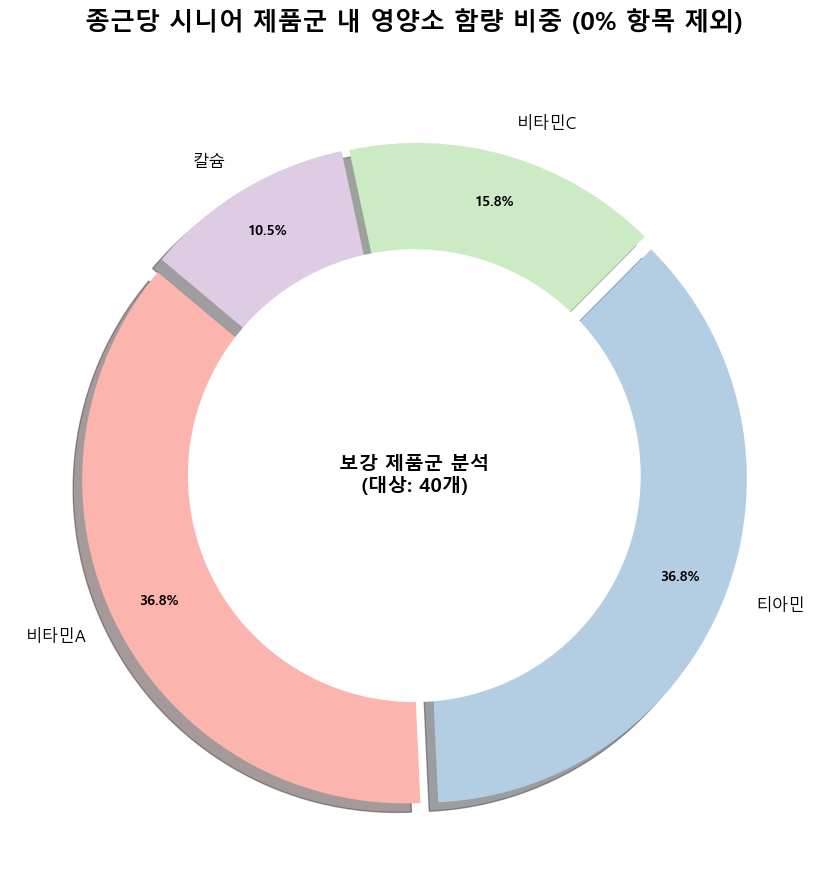

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def clean_nutrient_value(value):
    """문자열에서 숫자만 추출하여 함유 여부 판단"""
    if pd.isna(value) or value == '0' or value == '-':
        return 0.0
    try:
        # 숫자와 소수점만 추출
        num = re.sub(r'[^0-9.]', '', str(value))
        return float(num) if num else 0.0
    except:
        return 0.0

def plot_filtered_nutrient_pie(df):
    # 분석 타겟 결핍 영양소 리스트
    target_nutrients = ['칼슘', '칼륨', '비타민A', '비타민C', '나이아신', '엽산', '티아민']
    
    # 각 영양소별로 '함유된 제품의 수' 계산
    nutrient_counts = {}
    for col in target_nutrients:
        if col in df.columns:
            count = (df[col].apply(clean_nutrient_value) > 0).sum()
            # 0개인 항목은 제외 (0% 제외 로직)
            if count > 0:
                nutrient_counts[col] = count

    if not nutrient_counts:
        print("모든 결핍 영양소의 함유 제품이 0개입니다. 데이터를 다시 확인해주세요.")
        return

    # 데이터 정렬 (함유 제품 수가 많은 순서)
    sorted_counts = dict(sorted(nutrient_counts.items(), key=lambda item: item[1], reverse=True))
    
    labels = list(sorted_counts.keys())
    values = list(sorted_counts.values())
    
    # 2. 파이 차트 시각화
    plt.figure(figsize=(12, 9))
    
    # 세련된 컬러맵 사용
    colors = plt.cm.get_cmap('Pastel1')(range(len(labels)))
    
    # 파이 차트 생성
    wedges, texts, autotexts = plt.pie(
        values, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        pctdistance=0.85, 
        explode=[0.03] * len(labels), # 조각 간격 살짝 띄우기
        shadow=True
    )

    # 텍스트 가독성 설정
    plt.setp(autotexts, size=10, weight="bold")
    plt.setp(texts, size=12)

    # 도넛 스타일로 변경 (중앙에 정보 표시)
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    # 중앙 텍스트 추가
    total_products = len(df)
    plt.text(0, 0, f"보강 제품군 분석\n(대상: {total_products}개)", 
             ha='center', va='center', fontsize=14, fontweight='bold')

    plt.title('종근당 시니어 제품군 내 영양소 함량 비중 (0% 항목 제외)', 
              fontsize=18, fontweight='bold', pad=30)
    
    plt.tight_layout()
    plt.show()

# 실행
plot_filtered_nutrient_pie(df_info)

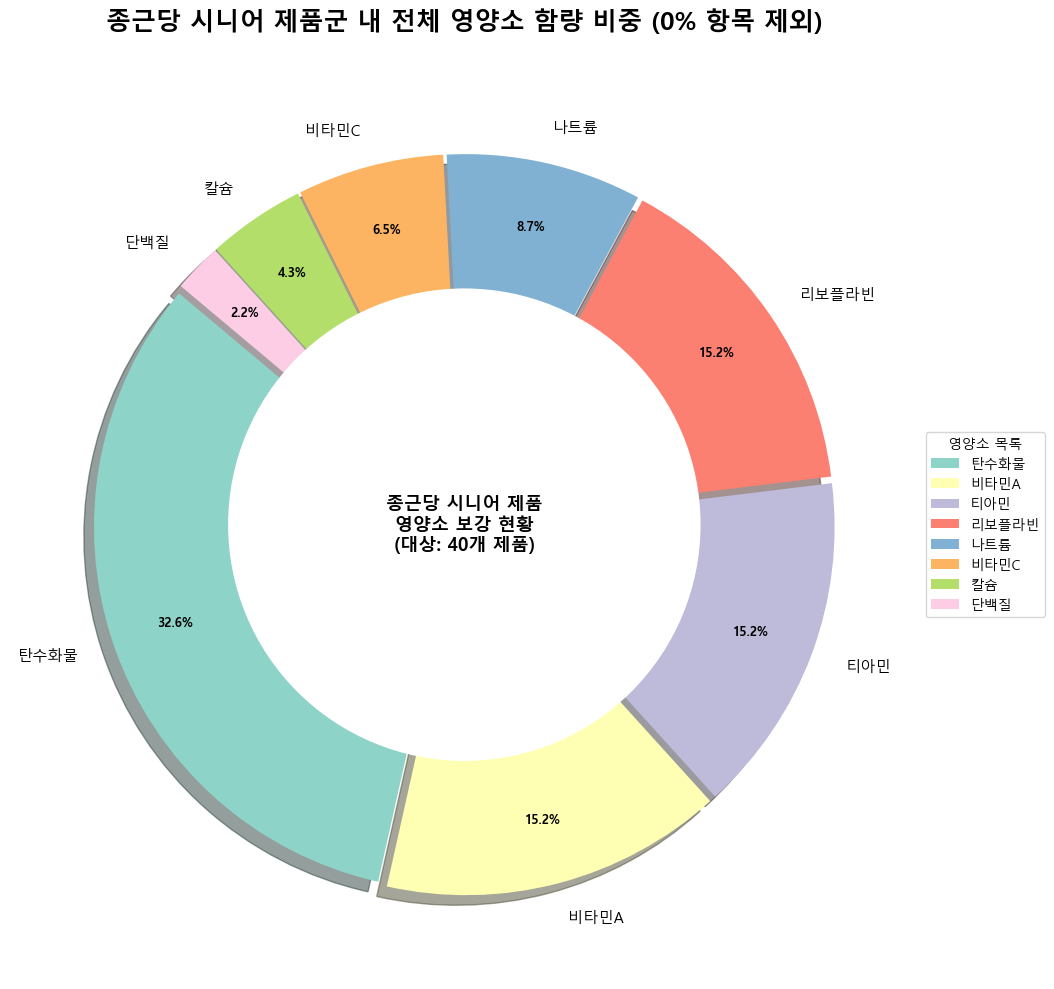

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def clean_nutrient_value(value):
    """문자열(10mg, 0 등)에서 숫자만 추출하여 함유 여부 판단"""
    if pd.isna(value) or value == '0' or value == '-' or value == '미검출':
        return 0.0
    try:
        # 숫자와 소수점만 추출
        num = re.sub(r'[^0-9.]', '', str(value))
        return float(num) if num else 0.0
    except:
        return 0.0

def plot_all_nutrients_pie(df):
    # 분석 대상 영양소 리스트 (사용자가 언급한 항목 및 주요 결핍 영양소 통합)
    target_nutrients = [
        '칼슘', '칼륨', '비타민A', '비타민C', '나이아신', '엽산', '티아민',
        '리보플라빈', '단백질', '탄수화물', '인', '철', '나트륨', '비타민D', '비타민E'
    ]
    
    # 데이터프레임에 실제 존재하는 컬럼이면서 함유 제품이 1개 이상인 것만 필터링
    nutrient_counts = {}
    for col in target_nutrients:
        if col in df.columns:
            # 해당 영양소가 0보다 큰 제품의 개수 카운트
            count = (df[col].apply(clean_nutrient_value) > 0).sum()
            if count > 0:
                nutrient_counts[col] = count

    if not nutrient_counts:
        print("분석 대상 영양소 중 함유된 제품이 없습니다. 컬럼명을 확인해주세요.")
        return

    # 데이터 정렬 (함유 제품 수가 많은 순서)
    sorted_counts = dict(sorted(nutrient_counts.items(), key=lambda item: item[1], reverse=True))
    
    labels = list(sorted_counts.keys())
    values = list(sorted_counts.values())
    
    # 2. 파이 차트 시각화
    plt.figure(figsize=(14, 10))
    
    # 항목이 많아졌으므로 더 다양한 색상 팔레트 사용
    colors = plt.cm.get_cmap('Set3')(range(len(labels)))
    
    # 도넛 차트 생성
    wedges, texts, autotexts = plt.pie(
        values, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        pctdistance=0.82, 
        explode=[0.02] * len(labels),
        shadow=True
    )

    # 텍스트 스타일 조정
    plt.setp(autotexts, size=9, weight="bold")
    plt.setp(texts, size=11)

    # 중앙 구멍 및 텍스트
    centre_circle = plt.Circle((0,0), 0.65, fc='white')
    plt.gcf().gca().add_artist(centre_circle)
    
    plt.text(0, 0, f"종근당 시니어 제품\n영양소 보강 현황\n(대상: {len(df)}개 제품)", 
             ha='center', va='center', fontsize=13, fontweight='bold')

    plt.title('종근당 시니어 제품군 내 전체 영양소 함량 비중 (0% 항목 제외)', fontsize=18, fontweight='bold', pad=30)
    
    # 범례 추가 (항목이 많을 경우 유용)
    plt.legend(wedges, labels, title="영양소 목록", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    
    plt.tight_layout()
    plt.show()

# 실행 (df_info가 원본 데이터를 담은 데이터프레임일 때)
plot_all_nutrients_pie(df_info)

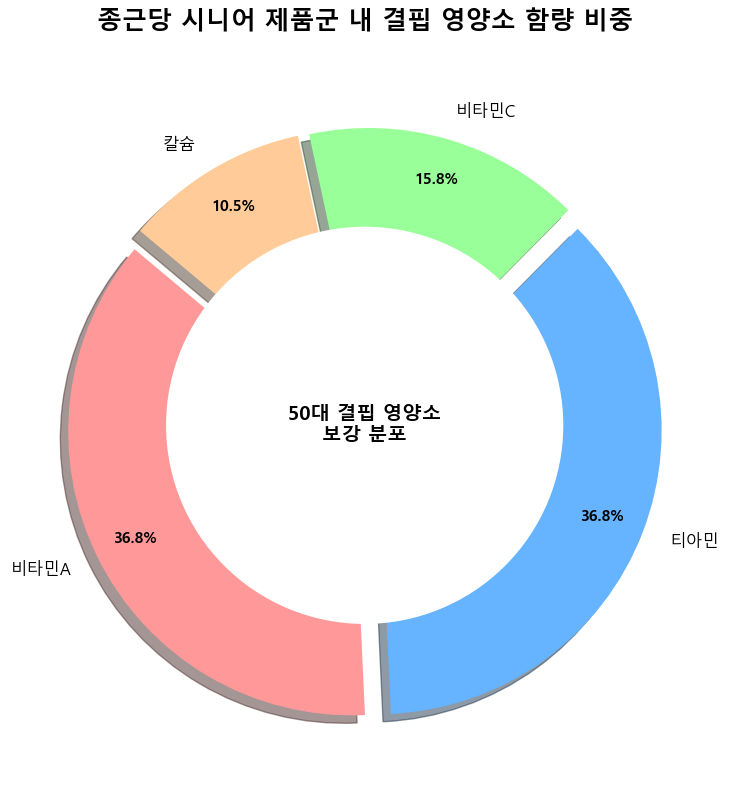

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def clean_nutrient_value(value):
    """문자열에서 숫자만 추출하여 함유 여부 판단"""
    if pd.isna(value) or value == '0' or value == '-' or value == '미검출':
        return 0.0
    try:
        num = re.sub(r'[^0-9.]', '', str(value))
        return float(num) if num else 0.0
    except:
        return 0.0

def plot_deficiency_target_pie(df):
    # 분석 타겟: 50대 이상 결핍 영양소 7종
    target_nutrients = ['칼슘', '칼륨', '비타민A', '나이아신', '비타민C', '엽산', '티아민']
    
    # 각 영양소별 함유 제품 수 계산
    nutrient_counts = {}
    for col in target_nutrients:
        if col in df.columns:
            count = (df[col].apply(clean_nutrient_value) > 0).sum()
            # 0%인 항목을 포함하여 보여줄지 제외할지 선택 가능 (여기서는 제외)
            if count > 0:
                nutrient_counts[col] = count

    if not nutrient_counts:
        print("선택하신 결핍 영양소를 포함한 제품이 데이터에 없습니다.")
        return

    # 데이터 정렬 및 준비
    sorted_counts = dict(sorted(nutrient_counts.items(), key=lambda item: item[1], reverse=True))
    labels = list(sorted_counts.keys())
    values = list(sorted_counts.values())
    
    # 2. 파이 차트 시각화
    plt.figure(figsize=(12, 8))
    
    # 가독성이 좋은 색상 팔레트
    colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6','#c4e17f']
    
    # 도넛 차트 생성
    wedges, texts, autotexts = plt.pie(
        values, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors[:len(labels)], 
        pctdistance=0.85, 
        explode=[0.05] * len(labels), 
        shadow=True
    )

    # 텍스트 스타일
    plt.setp(autotexts, size=11, weight="bold", color="black")
    plt.setp(texts, size=12)

    # 중앙 원 생성 (도넛 형태)
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    plt.gcf().gca().add_artist(centre_circle)

    # 중앙에 텍스트 표시
    plt.text(0, 0, "50대 결핍 영양소\n보강 분포", ha='center', va='center', fontsize=14, fontweight='bold')

    plt.title('종근당 시니어 제품군 내 결핍 영양소 함량 비중', fontsize=18, fontweight='bold', pad=30)
    
    plt.tight_layout()
    plt.show()

# 실행
plot_deficiency_target_pie(df_info)

## 종근당건강 시니어 건기식 제품 내 영양소 결합 빈도 분석  
#### 영양소 간의 상관관계 히트맵을 통해 '현재시장에 나온 제품들은 어떤 영양소끼리 주로 짝을 지어 출시되는가?'를 파악

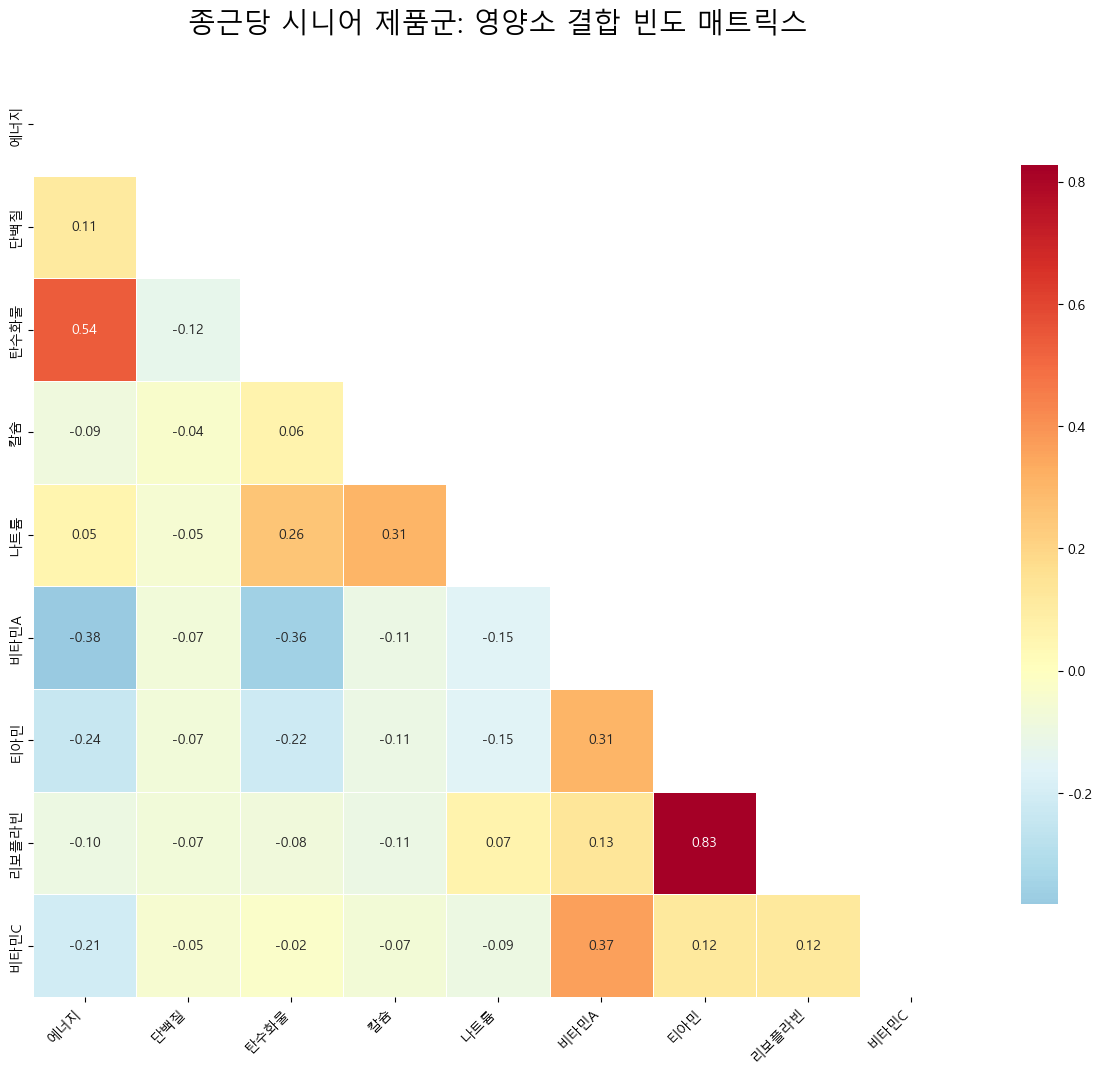

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re

# 1. 한글 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 전처리 함수 (숫자 추출 및 결측치 처리)
def clean_nutrient_value(value):
    if pd.isna(value) or str(value).strip() in ['0', '-', '미검출', '']:
        return 0.0
    try:
        # 숫자와 소수점만 추출
        num = re.sub(r'[^0-9.]', '', str(value))
        return float(num) if num else 0.0
    except:
        return 0.0

# 3. 오류 수정된 히트맵 함수
def plot_final_heatmap_fixed(df):
    # 분석에서 제외할 텍스트 컬럼
    exclude_cols = ['name', '섭취방식']
    nutrient_cols = [col for col in df.columns if col not in exclude_cols]
    
    # [수정 포인트 1] applymap 대신 최신 버전의 map 사용
    # 모든 데이터를 숫자형으로 변환 후 함유 여부(0/1)로 이진화
    df_binary = df[nutrient_cols].map(clean_nutrient_value)
    df_binary = (df_binary > 0).astype(int)
    
    # [수정 포인트 2] 분산이 0인 컬럼(모든 값이 0이거나 모든 값이 1인 컬럼) 제거
    # 상관계수는 변하지 않는 값(상수)에 대해 계산할 수 없어 오류나 빈 칸을 만듭니다.
    active_cols = [col for col in df_binary.columns if df_binary[col].nunique() > 1]
    df_active = df_binary[active_cols]
    
    if df_active.empty:
        print("분석 가능한(제품 간 차이가 있는) 영양소 데이터가 없습니다.")
        return

    # [수정 포인트 3] 상관관계 계산
    corr_matrix = df_active.corr()

    # 히트맵 시각화
    plt.figure(figsize=(15, 12))
    
    # 대각선 윗부분 가리기
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=True,          # 상관계수 숫자 표시
                cmap='RdYlBu_r',     # 빨강(강한 결합) ~ 파랑(독립적)
                fmt='.2f', 
                linewidths=0.5,
                center=0,            # 0을 기준으로 색상 밸런스 조정
                cbar_kws={"shrink": .8})

    plt.title('종근당 시니어 제품군: 영양소 결합 빈도 매트릭스', fontsize=20, pad=30)
    plt.xticks(rotation=45, ha='right')
    plt.show()

# 실행
plot_final_heatmap_fixed(df_info)

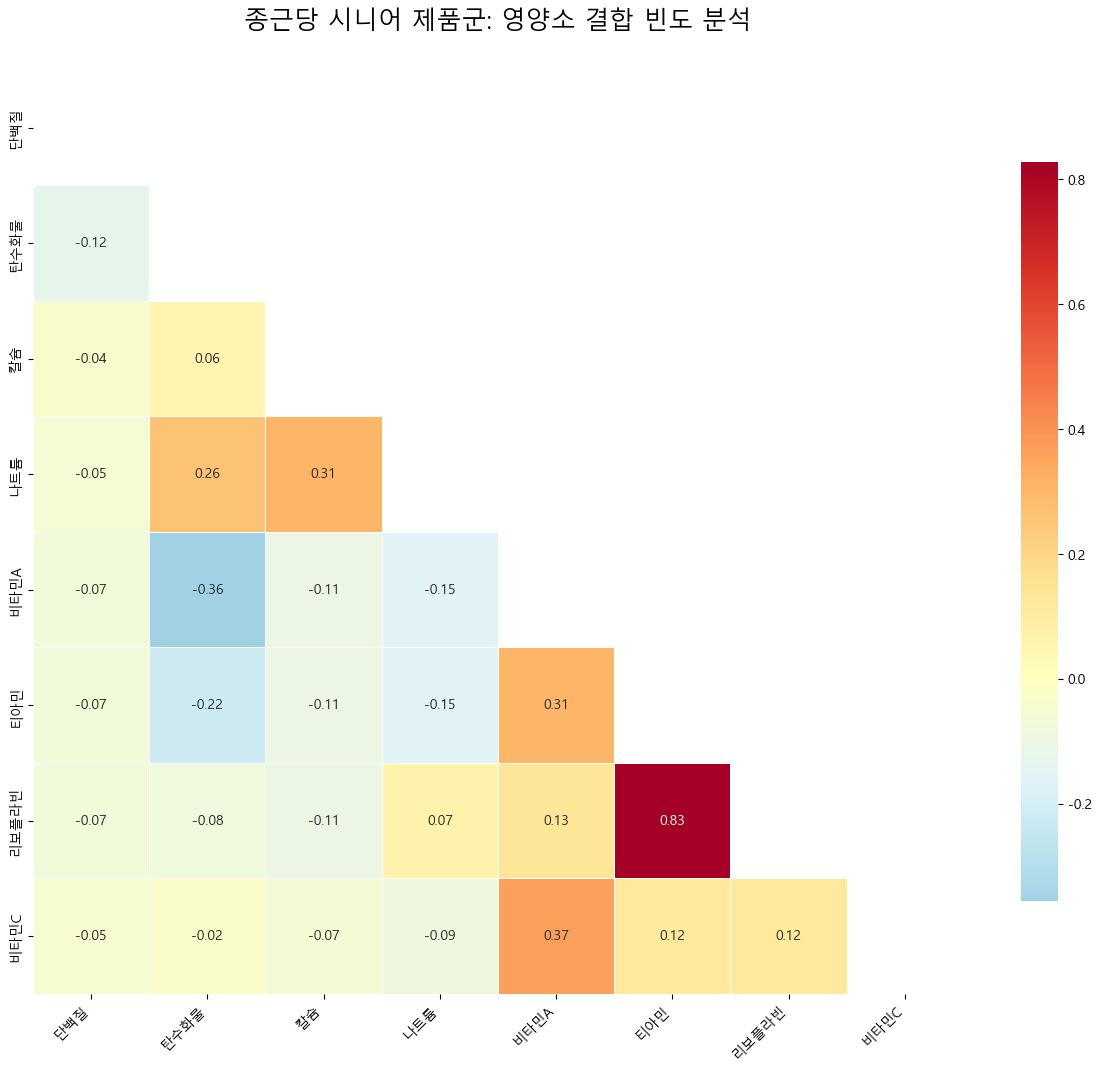

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re

# 1. 한글 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 전처리 함수
def clean_nutrient_value(value):
    if pd.isna(value) or str(value).strip() in ['0', '-', '미검출', '']:
        return 0.0
    try:
        num = re.sub(r'[^0-9.]', '', str(value))
        return float(num) if num else 0.0
    except:
        return 0.0

# 3. 에너지 제외 및 히트맵 출력 함수
def plot_final_matrix_no_energy(df):
    # [수정] 에너지 및 텍스트 컬럼 제외
    exclude_cols = ['name', '섭취방식', '에너지']
    nutrient_cols = [col for col in df.columns if col not in exclude_cols]
    
    # 데이터 이진화 (0 또는 1)
    df_binary = df[nutrient_cols].map(clean_nutrient_value)
    df_binary = (df_binary > 0).astype(int)
    
    # [핵심] 모든 제품에 다 들어있거나, 하나도 없는 컬럼(분산 0)은 상관관계 계산 불가하므로 제거
    active_cols = [col for col in df_binary.columns if df_binary[col].nunique() > 1]
    df_active = df_binary[active_cols]
    
    if df_active.empty:
        print("분석 가능한 영양소 데이터가 부족합니다.")
        return

    # 상관관계 계산
    corr_matrix = df_active.corr()

    # 시각화
    plt.figure(figsize=(15, 12))
    
    # 하삼각형 형태만 출력 (가독성 최적화)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=True, 
                cmap='RdYlBu_r', 
                fmt='.2f', 
                linewidths=0.5,
                center=0,
                cbar_kws={"shrink": .8})

    plt.title('종근당 시니어 제품군: 영양소 결합 빈도 분석', fontsize=18, pad=30)
    plt.xticks(rotation=45, ha='right')
    plt.show()

# 실행
plot_final_matrix_no_energy(df_info)

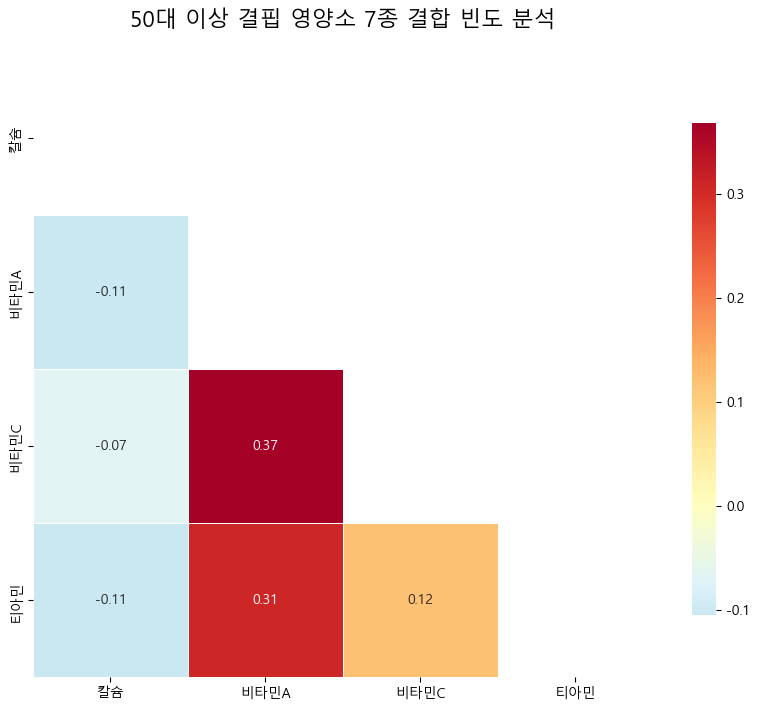

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re

# 1. 한글 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 전처리 함수
def clean_nutrient_value(value):
    if pd.isna(value) or str(value).strip() in ['0', '-', '미검출', '']:
        return 0.0
    try:
        num = re.sub(r'[^0-9.]', '', str(value))
        return float(num) if num else 0.0
    except:
        return 0.0

# 3. 타겟 영양소 분석 및 시각화
def plot_target_nutrient_matrix(df):
    # 분석할 7가지 핵심 결핍 영양소
    target_nutrients = ['칼슘', '칼륨', '비타민A', '나이아신', '비타민C', '엽산', '티아민']
    
    # 데이터프레임에 존재하는 컬럼만 필터링
    existing_targets = [col for col in target_nutrients if col in df.columns]
    
    # 데이터 이진화 (함유 시 1, 미함유 시 0)
    df_target_binary = df[existing_targets].map(clean_nutrient_value)
    df_target_binary = (df_target_binary > 0).astype(int)
    
    # 분산이 0인 컬럼(모든 값이 0이거나 1인 경우)은 상관관계 계산이 불가하므로 체크
    active_cols = [col for col in df_target_binary.columns if df_target_binary[col].nunique() > 1]
    df_active = df_target_binary[active_cols]
    
    # 상관관계 계산
    corr_matrix = df_active.corr()

    # 시각화
    plt.figure(figsize=(10, 8))
    
    # 중복 정보 제거를 위한 마스크 설정
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=True, 
                cmap='RdYlBu_r', 
                fmt='.2f', 
                linewidths=0.5,
                center=0,
                cbar_kws={"shrink": .8})

    plt.title('50대 이상 결핍 영양소 7종 결합 빈도 분석', fontsize=16, pad=25)
    plt.show()

# 실행
plot_target_nutrient_matrix(df_info)

## 종근당건강 건기식 제품 내 시니어 제품의 비중 분석

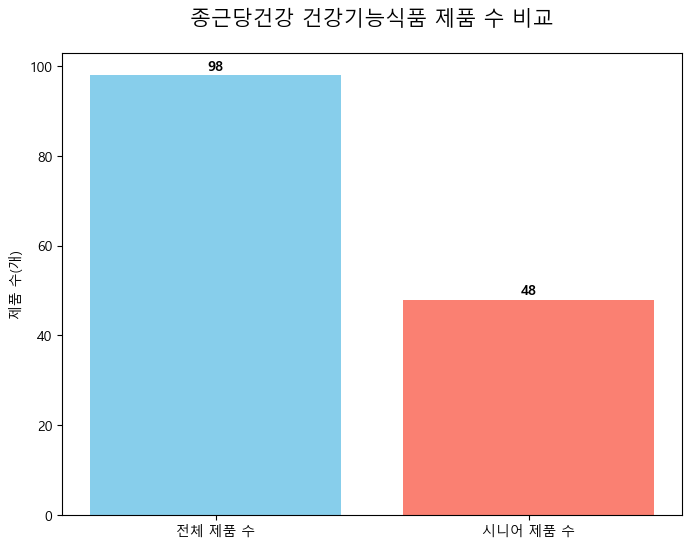

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 로드
df_product = pd.read_csv('product.csv')
df_ckd = pd.read_csv('종근당건강.csv')

# 2. 제품 수 계산
counts = {
    '전체 제품 수': len(df_product),
    '시니어 제품 수': len(df_ckd)
}

# 3. 시각화
plt.figure(figsize=(8, 6))
plt.rcParams['font.family'] = 'Malgun Gothic'

bars = plt.bar(counts.keys(), counts.values(), color=['skyblue', 'salmon'])

# 수치 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom', fontweight='bold')

plt.title('종근당건강 건강기능식품 제품 수 비교', fontsize=15, pad=20)
plt.ylabel('제품 수(개)')
plt.show()

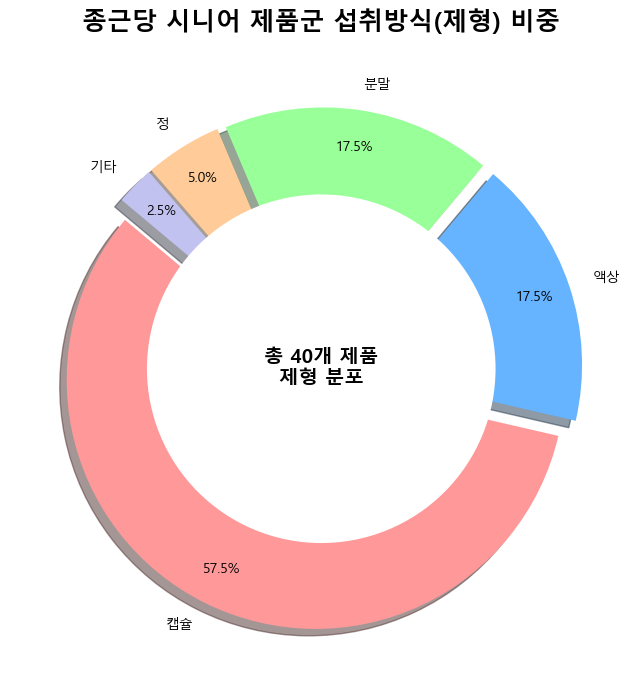

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드
df = pd.read_csv('종근당건강_영양성분정보.csv')

# 3. 섭취방식 빈도 계산
type_counts = df['섭취방식'].value_counts()

# 4. 시각화 (도넛 차트)
plt.figure(figsize=(10, 7))

# 색상 팔레트 설정
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0']

# 파이 차트 생성
wedges, texts, autotexts = plt.pie(
    type_counts, 
    labels=type_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors[:len(type_counts)],
    pctdistance=0.85,
    explode=[0.05] * len(type_counts),
    shadow=True
)

# 도넛 형태를 위한 중앙 원
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gcf().gca().add_artist(centre_circle)

# 중앙 텍스트
plt.text(0, 0, f'총 {len(df)}개 제품\n제형 분포', ha='center', va='center', fontsize=14, fontweight='bold')

plt.title('종근당 시니어 제품군 섭취방식(제형) 비중', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()